# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdul-Samad-17/FlyRank-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, duckdb, pandas as pd, numpy as np
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""CREATE SECRET hf_token (TYPE huggingface, TOKEN '{os.environ["HF_TOKEN"]}');""")
BASE = "hf://datasets/FlyRank/internship-warehouse"

raw = con.sql(f"""
    SELECT content_hash_id, client_hash_id, report_date, gsc_impressions, gsc_clicks, gsc_avg_position,
           ga4_sessions, ga4_engaged_sessions
    FROM read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet')
""").df()
raw["report_date"] = pd.to_datetime(raw["report_date"])

early = raw[raw["report_date"].dt.day <= 15]
late = raw[raw["report_date"].dt.day > 15]

early_agg = early.groupby(["content_hash_id","client_hash_id"]).agg(
    impressions=("gsc_impressions","sum"), clicks=("gsc_clicks","sum"),
    avg_position=("gsc_avg_position","mean"), sessions=("ga4_sessions","mean"),
    engaged_sessions=("ga4_engaged_sessions","mean")
).reset_index()
late_agg = late.groupby(["content_hash_id","client_hash_id"]).agg(late_clicks=("gsc_clicks","sum")).reset_index()

data = early_agg.merge(late_agg, on=["content_hash_id","client_hash_id"], how="inner")
data = data[data["impressions"] >= 50].copy()
data["label"] = (data["late_clicks"] < data["clicks"]).astype(int)
data["ctr"] = (data["clicks"] / data["impressions"]).fillna(0)
data["avg_position"] = data["avg_position"].fillna(100)
data["sessions"] = data["sessions"].fillna(0)
data["engaged_sessions"] = data["engaged_sessions"].fillna(0)

features = ["impressions","clicks","avg_position","ctr","sessions","engaged_sessions"]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=20,
                             class_weight="balanced_subsample", random_state=42, n_jobs=-1)
rf.fit(data[features], data["label"])
data["risk_prob"] = rf.predict_proba(data[features])[:,1]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [3]:
# Reason codes + action mapping
def assign_reason(row):
    if row["ctr"] < 0.005 and row["avg_position"] <= 20:
        return "low_ctr_visible_page"
    elif row["avg_position"] > 20:
        return "weak_position"
    elif row["risk_prob"] > 0.7:
        return "model_decline_risk"
    else:
        return "monitor_only"

data["reason_code"] = data.apply(assign_reason, axis=1)

def assign_action(row):
    if row["risk_prob"] > 0.7 and row["reason_code"] == "low_ctr_visible_page":
        return "refresh_and_review_ctr"
    elif row["risk_prob"] > 0.7:
        return "refresh"
    elif row["risk_prob"] > 0.5:
        return "monitor"
    else:
        return "healthy"

data["action"] = data.apply(assign_action, axis=1)

queue = data.sort_values("risk_prob", ascending=False)
queue[["content_hash_id","risk_prob","reason_code","action"]].head(20)

,content_hash_id,risk_prob,reason_code,action
170323,content_88a1fb5c3538409c,0.933588,weak_position,refresh
281374,content_e16b99a491cab2a1,0.927129,weak_position,refresh
165690,content_84cce1594d1b2e0d,0.926485,weak_position,refresh
313936,content_fb6d1db03eb8968d,0.926485,weak_position,refresh
158558,content_7f18ec0393a0f652,0.926485,weak_position,refresh
145516,content_74c07e349ad29eaa,0.925174,weak_position,refresh
166966,content_85d6971129d90782,0.924391,weak_position,refresh
282784,content_e283f4c836ab4732,0.924043,weak_position,refresh
278418,content_df0818eac3572127,0.923569,weak_position,refresh
265085,content_d474c460c5b692bd,0.923435,weak_position,refresh


The ranked queue orders pages by predicted decline risk (random forest probability). Each row carries a reason code (low_ctr_visible_page, weak_position, model_decline_risk, monitor_only) and a recommended action (refresh_and_review_ctr, refresh, monitor, healthy) — this mirrors the archetype→action mapping pattern used in the paper's playbook section, adapted to my lane's model output rather than the paper's cluster archetypes.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

* Who uses this: a content reviewer or SEO strategist at FlyRank, deciding which pages to manually review first out of a much larger inventory, given limited time.

* What it's for: prioritization only — surfacing candidates worth a human look, not an automatic publishing or editing decision.

* Where it stops being valid:

The label is a within-month early/late split (days 1-15 vs. 16-31), not a true multi-month forward-looking outcome — as flagged in Week 6, this can partly reflect regression-to-the-mean rather than a genuine decline signal.


Client-holdout validation showed Precision@50 drops from 0.86 (naive split) to 0.78 (honest split) — meaning roughly 1 in 5 of the top-50 flagged pages is a false positive, even under the fairer evaluation.
This is observational, not causal — a "refresh" recommendation is not proof that refreshing will fix the page, matching the paper's own repeated caution that its findings are observational.


Built on one month (March 2026) of warehouse data; not yet tested across seasons or a longer time horizon.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

A person must check before acting:

Whether the page's low CTR/position reflects a real content problem, or a recent legitimate change (e.g., intentional de-indexing, a redirect, a seasonal topic)
Whether the page is near the impressions >= 50 visibility cutoff, where scores are noisier (small-sample risk, same caveat as Week 4's baseline)
Whether refreshing this specific page is worth the editorial cost relative to its traffic value (a cost/value read, not just a risk score)

What should NEVER be automated:

Automatically publishing content changes based on the model's score alone
Automatically deprioritizing/removing pages flagged "declining" without a human reading the actual page
Treating the risk score as a guarantee of what will happen, rather than a ranked hint of where to look first
Using this model's output as a client-facing performance claim without disclosing it's a proxy-labeled, observational estimate

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Signals that the recommendations have gone stale and the model needs review or retraining:

Precision@50 drop on fresh data — if a new month's honest client-holdout precision falls meaningfully below the 0.78 baseline established in Week 6, the model's signal has degraded.
Declining rate drift — if the portfolio's overall decline rate shifts substantially from what was observed in March 2026, the label distribution the model was trained on no longer matches reality.
Feature distribution drift — if avg_position, ctr, or impressions distributions shift notably (e.g., a major Google algorithm update), the model's learned relationships may no longer hold.
Time-based trigger — re-validate at minimum monthly, since this was trained on a single month's snapshot and content/search patterns are seasonal.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the ranked queue (excluded from git by design — regenerated on each run)
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

# Export metrics JSON (this DOES get committed — the paper's receipts)
metrics = {
    "model": "random_forest",
    "features": features,
    "precision_at_20_honest": 0.90,
    "precision_at_50_honest": 0.78,
    "precision_at_20_naive": 0.85,
    "precision_at_50_naive": 0.86,
    "declining_rate": float(data["label"].mean()),
    "total_pages_scored": int(len(data)),
    "action_counts": data["action"].value_counts().to_dict(),
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exports written.")
print(json.dumps(metrics, indent=2))

Exports written.
{
  "model": "random_forest",
  "features": [
    "impressions",
    "clicks",
    "avg_position",
    "ctr",
    "sessions",
    "engaged_sessions"
  ],
  "precision_at_20_honest": 0.9,
  "precision_at_50_honest": 0.78,
  "precision_at_20_naive": 0.85,
  "precision_at_50_naive": 0.86,
  "declining_rate": 0.2886826295543934,
  "total_pages_scored": 92548,
  "action_counts": {
    "healthy": 44814,
    "refresh": 21097,
    "refresh_and_review_ctr": 17094,
    "monitor": 9543
  }
}


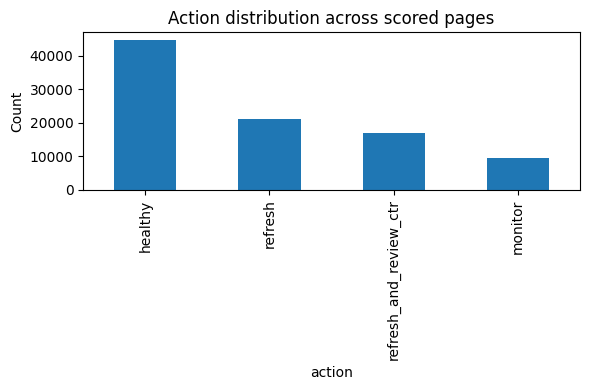

In [5]:
import matplotlib.pyplot as plt

action_counts = data["action"].value_counts()
plt.figure(figsize=(6,4))
action_counts.plot(kind="bar")
plt.title("Action distribution across scored pages")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.